# Annual European electricity-mix validation

This notebook builds annual SHRECC consumption mixes for the European countries represented by both source datasets. Historical years use Energy Charts; prospective years use ENTSO-E TYNDP automatically.

The workflow deliberately processes one year at a time. A full European year contains 8,760 hourly systems, so retaining all five hourly result datasets simultaneously would use considerable memory. Each compact annual table and Brightway database is preserved before the yearly pipeline object is released.

In [1]:
from gc import collect
from pathlib import Path

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from shrecc import NewDatabase
from shrecc.analysis import (
    compare_electricity_generation_mixes, # Collects electricity-generating activities along consumption tiers
    compare_electricity_lcia, # Produces LCIA comparisons of selected electricity mixes
)


## Configuration

`COUNTRIES` is the end-to-end European model coverage shared by Energy Charts, the DE TYNDP scenario, and the REMIND-EU topology. Moldova and Ukraine have concordance entries but no usable production or trade data in this TYNDP scenario. Iceland is absent from the source models; Kosovo is present in TYNDP but currently lacks a REMIND-EU region assignment. These countries are therefore excluded from the harmonized five-year comparison.

Energy Charts provides 8,760 hours for these historical years. The TYNDP scenario uses a 52-week model year containing 8,736 hours and ending on December 30.

Set `YEARS_TO_CREATE` to only the unfinished years when resuming an interrupted run. Annual tables for the other years are loaded from `OUTPUT_DIR`.

In [2]:
YEARS = [2021, 2025, 2035, 2040, 2050]
YEARS_TO_CREATE = YEARS.copy()
EXPECTED_HOURS = {2021: 8760, 2025: 8760, 2035: 8736, 2040: 8736, 2050: 8736}

COUNTRIES = [
    "AT", "BA", "BE", "BG", "CH", "CZ", "DE", "DK",
    "EE", "ES", "FI", "FR", "GR", "HR", "HU", "IE", "IT", "LT",
    "LU", "LV", "ME", "MK", "NL", "NO", "PL", "PT",
    "RO", "RS", "SE", "SI", "SK", "UK",
]

PROJECT_NAME = "SHRECCei311"
SCENARIO = "DE"
CLIMATE_YEAR = 2009

BACKGROUND_DATABASES = {
    2021: "ecoinvent-3.11-cutoff",
    2025: "ecoinvent-3.11-cutoff",
    2035: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10",
    2040: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10",
    2050: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2026-07-10",
}
FOREGROUND_DATABASES = {
    year: f"shrecc_annual_europe_{year}" for year in YEARS
}
BACKGROUND_LABELS = {
    2021: "ecoinvent 3.11",
    2025: "ecoinvent 3.11",
    2035: "premise 2035",
    2040: "premise 2040",
    2050: "premise 2050",
}

CLIMATE_METHOD = (
    "ecoinvent-3.11",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)

OUTPUT_DIR = Path("export") / "annual_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WRITE_DATABASES = True
COUNTRY_TO_PLOT = "FR"

In [3]:
bd.projects.set_current(PROJECT_NAME)

missing_backgrounds = {
    year: name
    for year, name in BACKGROUND_DATABASES.items()
    if name not in bd.databases
}
if missing_backgrounds:
    raise ValueError(f"Missing background databases: {missing_backgrounds}")
if CLIMATE_METHOD not in bd.methods:
    raise ValueError(f"Brightway method is not installed: {CLIMATE_METHOD}")

display(
    pd.DataFrame(
        {
            "source": ["Energy Charts", "Energy Charts", "TYNDP", "TYNDP", "TYNDP"],
            "background": pd.Series(BACKGROUND_DATABASES),
            "foreground": pd.Series(FOREGROUND_DATABASES),
        },
        index=YEARS,
    ).rename_axis("year")
)

,source,background,foreground
year,,,
2021,Energy Charts,ecoinvent-3.11-cutoff,shrecc_annual_europe_2021
2025,Energy Charts,ecoinvent-3.11-cutoff,shrecc_annual_europe_2025
2035,TYNDP,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2...,shrecc_annual_europe_2035
2040,TYNDP,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2...,shrecc_annual_europe_2040
2050,TYNDP,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2...,shrecc_annual_europe_2050


## Create annual mixes

No hour range is supplied. Historical years contain every hour from January 1 at 00:00 through December 31 at 23:00, or 8,760 timestamps. Each TYNDP model year contains 8,736 timestamps because the source scenarios cover exactly 52 weeks, from January 1 through December 30.

The cutoff is disabled for validation so the mapped shares can be compared without hiding small technologies in a residual category. `consumption_mix_volume` is omitted to avoid duplicating the largest result array; it is not required to write the normalized annual inventories.

The annual inventories use `consumption_profile="national_demand"`: hourly normalized mixes are weighted by measured national electricity consumption before aggregation. This is the closest SHRECC comparison with annual ecoinvent and premise inventories, which implicitly represent volume-weighted annual supply.

In [5]:
annual_tables = {}
run_records = []

for year in YEARS:
    table_path = OUTPUT_DIR / f"annual_mix_{year}.csv"

    if year not in YEARS_TO_CREATE:
        if not table_path.is_file():
            raise FileNotFoundError(
                f"No saved table for {year}; add it to YEARS_TO_CREATE"
            )
        annual_tables[year] = pd.read_csv(table_path, index_col=[0, 1, 2, 3])
        run_records.append(
            {
                "year": year,
                "source": "saved table",
                "hours": EXPECTED_HOURS[year],
                "activities": len(annual_tables[year]),
                "foreground database": FOREGROUND_DATABASES[year],
            }
        )
        continue

    print(f"\nCreating annual European mix for {year}")
    annual_database = NewDatabase(
        years=year,
        countries=COUNTRIES,
        project_name=PROJECT_NAME,
        bg_db_name=BACKGROUND_DATABASES[year],
        my_db_name=FOREGROUND_DATABASES[year],
        scenario=SCENARIO,
        climate_year=CLIMATE_YEAR,
        time_range=[
            f"{year}-01-01 00:00:00",
            f"{year}-12-31 23:00:00",
        ],
        cutoff=0,
        include_cutoff=False,
        strict=False,
        network=True,
        zero_consumption="month_hour_average",
        consumption_profile="national_demand",
        include_consumption_mix_volume=False,
        download=True,
        verbose=True,
    ).create()

    hour_count = annual_database.results(year).sizes["time"]
    if hour_count != EXPECTED_HOURS[year]:
        raise ValueError(
            f"Expected {EXPECTED_HOURS[year]} hours for {year}; found {hour_count}"
        )

    annual_tables[year] = annual_database.table(year).copy()
    annual_tables[year].to_csv(table_path)

    if WRITE_DATABASES:
        annual_database.write()

    run_records.append(
        {
            "year": year,
            "source": annual_database.sources[year],
            "hours": hour_count,
            "activities": len(annual_tables[year]),
            "foreground database": FOREGROUND_DATABASES[year],
        }
    )

    del annual_database
    collect()

run_summary = pd.DataFrame(run_records).set_index("year")
display(run_summary)


Creating annual European mix for 2021
Creating energy_charts electricity mix for 2021


C:\Users\Gibon\AppData\Local\Temp\ipykernel_2292\534230329.py:46: UserWarning: Energy Charts activity mapping gaps for 2021 were assigned to source-country high-voltage production mixes. Fallback share by consumer: ME 44.3%, EE 40.3%, LT 38.4%, LV 25.0%, NL 24.6%. Largest source-technology gaps: EE/Fossil oil shale 29.2%, BA/Hard coal 23.6%, ME/Hydro 22.6%, NL/Others 21.2%, BY/Import balance 20.6%. See mapping_report(2021) for the full report.
  ).create()
100%|██████████| 32/32 [00:02<00:00, 14.02it/s]


15:00:29+0200 [info     ] Vacuuming database            

Creating annual European mix for 2025
Creating energy_charts electricity mix for 2025


C:\Users\Gibon\AppData\Local\Temp\ipykernel_2292\534230329.py:46: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: ME 35.4%, NL 34.9%, EE 18.4%, NO 17.5%, BE 13.5%. Largest source-technology gaps: NL/Others 32.1%, ME/Hydro 21.5%, NO/Hydro run-of-river 16.7%, EE/Fossil oil shale 15.0%, AL/Import balance 12.9%. See mapping_report(2025) for the full report.
  ).create()
100%|██████████| 32/32 [00:03<00:00,  8.99it/s]


15:03:44+0200 [info     ] Vacuuming database            

Creating annual European mix for 2035
Creating tyndp electricity mix for 2035
2026-08-31 15:07:14 Loading TYNDP pickle files
2026-08-31 15:07:15 Parsing hourly datetime index
2026-08-31 15:07:16 Loading technology and country mappings
2026-08-31 15:07:16 Aggregating hourly production by country and technology


...

D:\shrecc_project\shrecc\shrecc\tyndp.py:305: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)


2026-08-31 15:13:34 Combining production and trade into Z_gross
2026-08-31 15:13:34 Built Z_gross with shape (8736, 520)
2026-08-31 15:13:34 Preparing canonical production and trade volumes
2026-08-31 15:13:35 Solving hourly country trade systems
2026-08-31 15:13:44 Built consumption results with sizes {'time': 8736, 'producer_country': 35, 'technology': 32, 'exporter_country': 35, 'importer_country': 35, 'consumer_country': 35, 'source_country': 35}
Using fallback activity:electricity production, at hydrogen-fired combined cycle power plant, by auto-thermal reforming of natural gas, RER for requested geography DEU
Using fallback activity:electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m, RER for requested geography ECE
Using fallback activity:electricity production, at hydrogen-fired combined cycle power plant, by auto-thermal reforming of natural gas, RER for requested geography ECE
Using fallback activity:electricity production, at o

100%|██████████| 32/32 [00:01<00:00, 24.68it/s]


15:13:55+0200 [info     ] Vacuuming database            


,source,hours,activities,foreground database
year,,,,
2021,energy_charts,8760,826,shrecc_annual_europe_2021
2025,energy_charts,8760,826,shrecc_annual_europe_2025
2035,tyndp,8736,746,shrecc_annual_europe_2035
2040,tyndp,8736,746,shrecc_annual_europe_2040
2050,tyndp,8736,746,shrecc_annual_europe_2050


In [6]:
annual_mix_checks = pd.concat(
    {
        year: table.sum(axis=0).rename("sum")
        for year, table in annual_tables.items()
    },
    names=["year", "country"],
).to_frame()
annual_mix_checks["difference from one"] = annual_mix_checks["sum"] - 1

if not np.allclose(annual_mix_checks["sum"], 1, atol=1e-8):
    display(annual_mix_checks.loc[~np.isclose(annual_mix_checks["sum"], 1, atol=1e-8)])
    print("At least one annual mapped mix does not sum to one")

display(annual_mix_checks.groupby(level="year").agg(["min", "max"]))

sum      difference from one              
      min  max                 min           max
year                                            
2021  1.0  1.0        3.708145e-14  3.266278e-10
2025  1.0  1.0        2.886580e-14  2.533649e-10
2035  1.0  1.0       -2.109424e-15  2.442491e-15
2040  1.0  1.0       -1.887379e-15  2.664535e-15
2050  1.0  1.0       -2.220446e-15  1.554312e-15

## Compare technology mixes

Both sides are resolved from electricity delivered to the final consumer: the written SHRECC foreground activity and the background database's country-level `market for electricity, low voltage`. Starting at low voltage includes distributed photovoltaic generation that is absent from a high-voltage production mix.

The resolver follows only positive electricity exchanges through voltage transformation, market, import, country, and IAM-region wrappers. It stops at generating activities and normalizes their supplied volumes. Iterative propagation handles premise cycles between country and regional mixes without relying on a fixed graph depth. Network construction and other non-electricity exchanges are excluded from this composition comparison.

In [7]:
comparison_foregrounds = {"SHRECC": FOREGROUND_DATABASES}


In [8]:
mix_comparison, mix_comparison_gaps, mix_resolution_diagnostics = (
    compare_electricity_generation_mixes(
        comparison_foregrounds,
        BACKGROUND_DATABASES,
        countries=COUNTRIES,
        years=YEARS,
    )
)

mix_comparison["background"] = mix_comparison["year"].map(BACKGROUND_LABELS)
mix_comparison.to_csv(OUTPUT_DIR / "technology_mix_comparison.csv", index=False)
mix_resolution_diagnostics.to_csv(
    OUTPUT_DIR / "technology_mix_resolution_diagnostics.csv",
    index=False,
)

display(
    mix_comparison_gaps
    if not mix_comparison_gaps.empty
    else "No comparison gaps"
)
display(mix_resolution_diagnostics.head())
display(mix_comparison.head())


'No comparison gaps'

,year,country,model,root activity,iterations,terminal generation volume,remaining wrapper volume,nonstandard terminal volume
0,2021,AT,SHRECC,"electricity, consumption mix, 2021",3,1.000000,0.000000e+00,0.000000
1,2021,AT,Background,"market for electricity, low voltage",35,1.064154,8.586426e-11,0.005926
2,2021,BA,SHRECC,"electricity, consumption mix, 2021",3,1.000000,0.000000e+00,0.000000
3,2021,BA,Background,"market for electricity, low voltage",40,1.158090,8.181691e-11,0.000000
4,2021,BE,SHRECC,"electricity, consumption mix, 2021",3,1.000000,0.000000e+00,0.000000


,year,country,model,technology,share,background
0,2021,AT,SHRECC,"electricity production, hydro, run-of-river",0.361161,ecoinvent 3.11
1,2021,AT,SHRECC,"electricity production, wind, 1-3MW turbine, o...",0.108820,ecoinvent 3.11
2,2021,AT,SHRECC,"electricity production, hydro, pumped storage",0.074954,ecoinvent 3.11
3,2021,AT,SHRECC,"electricity production, hydro, reservoir, alpi...",0.064691,ecoinvent 3.11
4,2021,AT,SHRECC,"electricity production, nuclear, pressure wate...",0.064471,ecoinvent 3.11


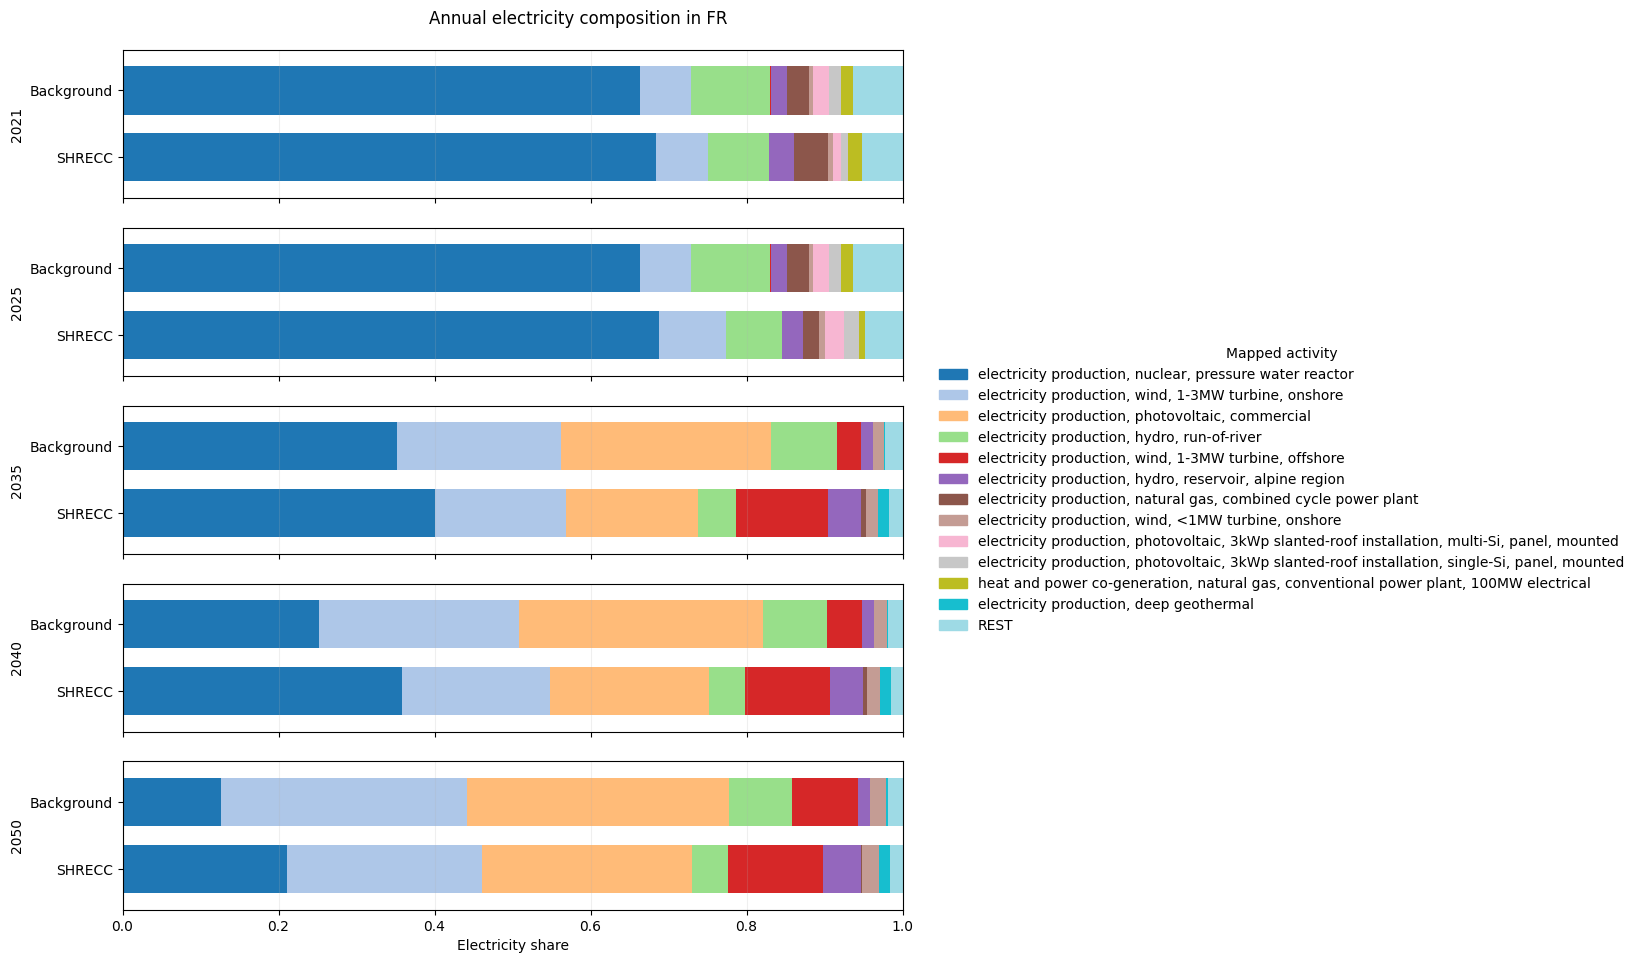

In [9]:
def plot_mix_comparison(country, top_n=12):

    country_data = mix_comparison.loc[mix_comparison["country"] == country].copy()

    if country_data.empty:
        raise ValueError(f"No mix-comparison data for {country}")

    leading_technologies = (
        country_data.groupby("technology")["share"]
        .sum()
        .nlargest(top_n)
        .index
    )
    country_data["technology_plot"] = country_data["technology"].where(
        country_data["technology"].isin(leading_technologies),
        "REST",
    )
    technologies = list(leading_technologies) + ["REST"]
    colors = dict(
        zip(technologies, plt.cm.tab20(np.linspace(0, 1, len(technologies))))
    )

    fig, axes = plt.subplots(
        len(YEARS),
        1,
        figsize=(12, 10),
        sharex=True,
        squeeze=False,
    )
    axes = axes[:, 0]

    for year, ax in zip(YEARS, axes):
        yearly = country_data.loc[country_data["year"] == year]
        plotted = yearly.pivot_table(
            index="model",
            columns="technology_plot",
            values="share",
            aggfunc="sum",
            fill_value=0,
        ).reindex(index=["SHRECC", "Background"], columns=technologies, fill_value=0)
        plotted.plot.barh(
            stacked=True,
            ax=ax,
            color=[colors[column] for column in plotted.columns],
            legend=False,
            width=0.72,
        )
        ax.set(ylabel=str(year), xlim=(0, 1))
        ax.grid(axis="x", alpha=0.2)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[label], label=label)
        for label in technologies
    ]
    fig.legend(
        handles=handles,
        title="Mapped activity",
        loc="center left",
        bbox_to_anchor=(0.79, 0.5),
        frameon=False,
    )
    axes[-1].set_xlabel("Electricity share")
    fig.suptitle(f"Annual electricity composition in {country}")
    fig.subplots_adjust(left=0.12, right=0.77, top=0.94, bottom=0.08, hspace=0.2)
    return fig, axes


plot_mix_comparison(COUNTRY_TO_PLOT);

## Compare climate-change impacts

For every country and year, this section compares 1 kWh from the annual SHRECC foreground activity with 1 kWh from the corresponding ecoinvent or premise `market for electricity, low voltage`. This is the delivered-electricity boundary used for the resolved technology comparison above and includes distributed generation. The impact category is EF v3.1 climate change, GWP100.

The calculations are batched by year so only one foreground/background pair needs to be active in each `MultiLCA`. SHRECC currently uses a simplified, non-regionalized representation of network infrastructure, so differences reflect both electricity composition and the remaining network-model boundary difference.

In [10]:
lcia_results, lcia_gaps = compare_electricity_lcia(
    comparison_foregrounds,
    BACKGROUND_DATABASES,
    countries=COUNTRIES,
    years=YEARS,
    method=CLIMATE_METHOD,
    verbose=True,
)
lcia_results["background"] = lcia_results["year"].map(BACKGROUND_LABELS)


Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2021
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2025
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2035
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2040
Calculating ('ecoinvent-3.11', 'EF v3.1', 'climate change', 'global warming potential (GWP100)') for 2050


In [11]:
lcia_results.to_csv(OUTPUT_DIR / "climate_change_results.csv", index=False)
display(lcia_gaps if not lcia_gaps.empty else "No LCIA activity gaps")

lcia_comparison = lcia_results.pivot_table(
    index=["year", "country"],
    columns="model",
    values="score",
).rename_axis(columns=None)
lcia_comparison["difference"] = (
    lcia_comparison["SHRECC"] - lcia_comparison["Background"]
)
lcia_comparison["relative difference (%)"] = (
    100 * lcia_comparison["difference"] / lcia_comparison["Background"]
)
lcia_comparison.to_csv(OUTPUT_DIR / "climate_change_comparison.csv")
display(lcia_comparison)


'No LCIA activity gaps'

Background    SHRECC  difference  relative difference (%)
year country                                                           
2021 AT         0.248834  0.256767    0.007933                 3.188007
     BA         0.860284  0.720406   -0.139878               -16.259509
     BE         0.179910  0.187061    0.007151                 3.974834
     BG         0.518322  0.598823    0.080501                15.530994
     CH         0.030125  0.108049    0.077924               258.671262
...                  ...       ...         ...                      ...
2050 RS         0.015643  0.010394   -0.005249               -33.552641
     SE         0.013894  0.018666    0.004772                34.348392
     SI         0.012127  0.018530    0.006403                52.797366
     SK         0.011946  0.011696   -0.000250                -2.095230
     UK         0.012352  0.029370    0.017018               137.771710

[160 rows x 4 columns]

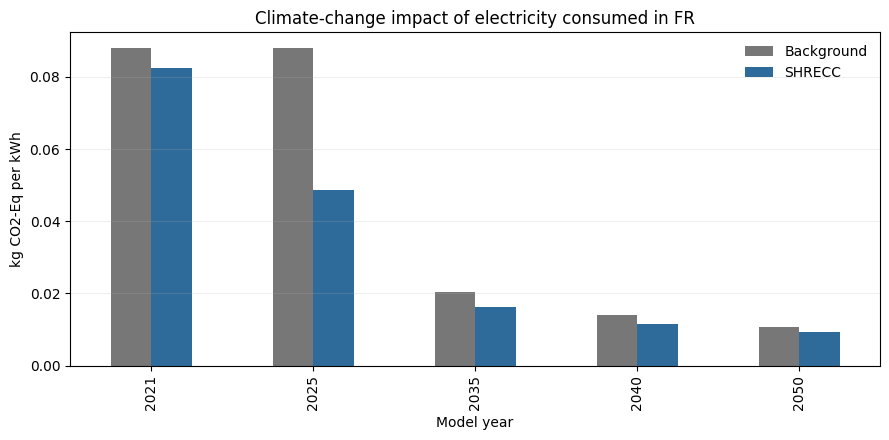

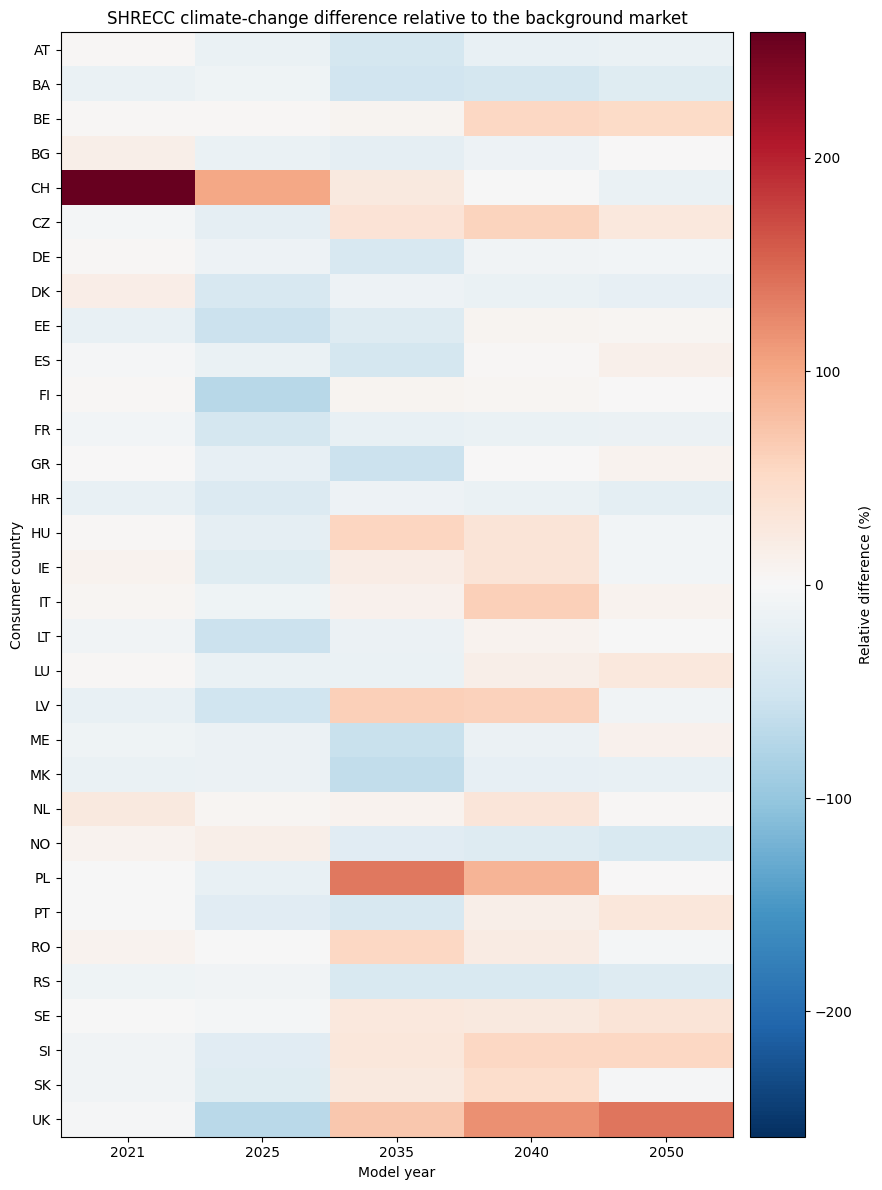

In [12]:
method_unit = bd.Method(CLIMATE_METHOD).metadata.get("unit", "kg CO2-eq")

country_lcia = (
    lcia_results.loc[lcia_results["country"] == COUNTRY_TO_PLOT]
    .pivot(index="year", columns="model", values="score")
    .reindex(YEARS)
)
ax = country_lcia.plot.bar(
    figsize=(9, 4.5),
    color={"SHRECC": "#2F6B9A", "Background": "#777777"},
)
ax.set(
    title=f"Climate-change impact of electricity consumed in {COUNTRY_TO_PLOT}",
    xlabel="Model year",
    ylabel=f"{method_unit} per kWh",
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

relative_difference = (
    lcia_comparison["relative difference (%)"]
    .unstack("year")
    .reindex(index=COUNTRIES, columns=YEARS)
)
finite_values = relative_difference.to_numpy()[
    np.isfinite(relative_difference.to_numpy())
]
color_limit = max(abs(finite_values).max(), 1) if finite_values.size else 1

fig, ax = plt.subplots(figsize=(9, 12))
image = ax.imshow(
    relative_difference,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)
ax.set(
    title="SHRECC climate-change difference relative to the background market",
    xlabel="Model year",
    ylabel="Consumer country",
    xticks=np.arange(len(YEARS)),
    yticks=np.arange(len(COUNTRIES)),
    xticklabels=YEARS,
    yticklabels=COUNTRIES,
)
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Relative difference (%)")
plt.tight_layout()

In [18]:
relative_difference[2021].abs().sort_values(ascending=False)

country
CH    258.671262
NL     25.727669
HR     19.111090
LV     18.581158
EE     18.580207
MK     17.447992
BA     16.259509
DK     16.188606
BG     15.530994
ME     11.648559
RS     11.202097
LT      9.505344
RO      9.152094
SK      8.776682
NO      8.703951
SI      8.239151
IE      8.159253
FR      6.198916
CZ      5.015011
IT      4.486061
FI      4.041686
BE      3.974834
UK      3.739677
HU      3.635082
AT      3.188007
ES      3.114572
LU      2.931172
DE      2.776363
PL      1.264347
GR      0.868642
SE      0.627969
PT      0.371609
Name: 2021, dtype: float64

## Saved outputs

The restartable annual tables and complete comparison results are written under `notebooks/export/annual_validation`:

- `annual_mix_<year>.csv`: mapped SHRECC annual mix for every consumer country.
- `technology_mix_comparison.csv`: long-form SHRECC/background composition comparison.
- `climate_change_results.csv`: individual EF v3.1 climate-change scores.
- `climate_change_comparison.csv`: absolute and relative SHRECC/background differences.